# Quantum Optics - Homework 2 - Damping the oscillations

## Jan Chelmecki

In [53]:
import numpy as np
import matplotlib.pyplot as plt

A characteristic of a squuezed state is the periodic oscillation of the width of the momentum wavefunction - as an elliptically shaped Wigner function rotates, its projection onto the $p$ axis oscillates in time, according to the analitical formula.

$$
\Delta p^2 = \frac{1}{2} \Big[
1 + \frac{(\omega \tau_1)^2}{2}
 − \omega \tau_1
\sqrt{
1 + \frac{(\omega \tau_1)^2}{4}}
\cos(2 \omega \tau_2 − \phi)
\Big]
\qquad
\text{where}
\qquad
\phi = \tan^{−1} \Big( \frac{2}{\omega \tau_1} \Big)
$$

This describes a perfect oscillation. Let's plot it.

Text(0, 0.5, '$\\sqrt{\\Delta p^2}/ \\sqrt{\\Delta p_0^2}$')

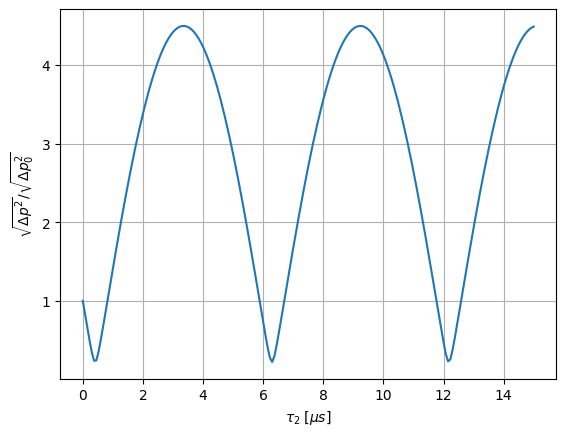

In [54]:
tau1 = 8.0
omega = 0.085*2*np.pi
phi = np.arctan( 2/(omega*tau1) )

tau2 = np.linspace(0,15,201)

dp2 = 1/2* (1 + (omega*tau1)**2/2 - (omega*tau1)* np.sqrt(1+(omega*tau1)**2 /4) * np.cos(2*omega*tau2 - phi))

plt.plot(tau2, np.sqrt(dp2/dp2[0]))
plt.grid()
plt.xlabel(r'$\tau_2 \; [\mu s]$')
plt.ylabel(r'$\sqrt{\Delta p^2}/ \sqrt{\Delta p_0^2}$')

However, what was measured in the experiment was the superposed signal from different potential wells with slightly diffent oscillator frequencies. As a result, the different $\Delta p^2$ oscillations have different frequencies, and so, as time elapses, they will slowly detune, and the overall amplitude will decrease. We'll model the $\omega$ distribution with a Gaussian.

Let's try
$$
\Delta p^2 = \int g(\omega) \cdot \Delta p^2_{\omega} \; d\omega
$$
with
$$
g(\omega) = \frac{1}{\Delta \omega \sqrt{2\pi }} \exp\Big(-\frac{(\omega-\omega_0)^2}{2(\Delta \omega)^2}\Big)
$$

Text(0, 0.5, '$\\sqrt{\\Delta p^2}/ \\sqrt{\\Delta p_0^2}$')

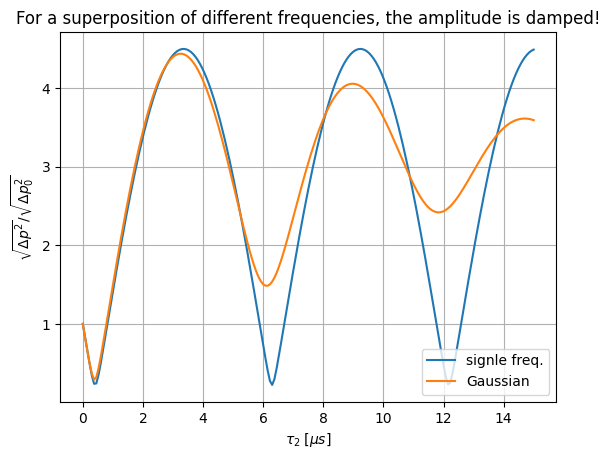

In [55]:
def g(omega, omega0, domega):
    return np.exp(- (omega-omega0)**2/2/domega**2)

omega0 = 0.085*2*np.pi
domega = 0.1*omega0
omegas = np.linspace(omega0-domega*4, omega0+domega*4, 201)

dp2_mat = np.zeros((tau2.size, omegas.size))
for i in range(len(omegas)):
    omega = omegas[i]
    phi = np.arctan( 2/(omegas[i]*tau1) )
    dp2_mat[:,i] = 1/2* (1 + (omega*tau1)**2 /2 - (omega*tau1)* np.sqrt(1+(omega*tau1)**2 /4) * np.cos(2*omega*tau2 - phi)) * g(omega, omega0, domega)
#end

#integrate over omega
dp2_damped = ( np.sum(dp2_mat, 1) - 0.5*(dp2_mat[:,0]+dp2_mat[:,-1]) ) * (omegas[1]-omegas[0]) / (domega*np.sqrt(2*np.pi))
plt.plot(tau2, np.sqrt(dp2/dp2[0]), label="signle freq.")
plt.plot(tau2, np.sqrt(dp2_damped/dp2[0]), label="Gaussian")
plt.legend()
plt.grid()
plt.xlabel(r'$\tau_2 \; [\mu s]$')
plt.title("For a superposition of different frequencies, the amplitude is damped!")
plt.ylabel(r'$\sqrt{\Delta p^2}/ \sqrt{\Delta p_0^2}$')

Sadly, this is mathes the figure in the article only quantitatively. Trying some other standard deviations for the Gaussian does not bring us closer to the article data.

<>:19: SyntaxWarning: invalid escape sequence '\D'
<>:21: SyntaxWarning: invalid escape sequence '\D'
<>:23: SyntaxWarning: invalid escape sequence '\D'
<>:25: SyntaxWarning: invalid escape sequence '\D'
<>:19: SyntaxWarning: invalid escape sequence '\D'
<>:21: SyntaxWarning: invalid escape sequence '\D'
<>:23: SyntaxWarning: invalid escape sequence '\D'
<>:25: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipython-input-4289447439.py:19: SyntaxWarning: invalid escape sequence '\D'
  plt.plot(tau2, np.sqrt(dp2_damped/dp2[0]), label="Gaussian $\Delta \omega = 0.05 \omega_0$", alpha = 0.5)
/tmp/ipython-input-4289447439.py:21: SyntaxWarning: invalid escape sequence '\D'
  plt.plot(tau2, np.sqrt(dp2_damped/dp2[0]), label="Gaussian $\Delta \omega = 0.1 \omega_0$", alpha = 0.5)
/tmp/ipython-input-4289447439.py:23: SyntaxWarning: invalid escape sequence '\D'
  plt.plot(tau2, np.sqrt(dp2_damped/dp2[0]), label="Gaussian $\Delta \omega = 0.2 \omega_0$", alpha=0.5)
/tmp/ipython-input-4289447439

Text(0, 0.5, '$\\sqrt{\\Delta p^2}/ \\sqrt{\\Delta p_0^2}$')

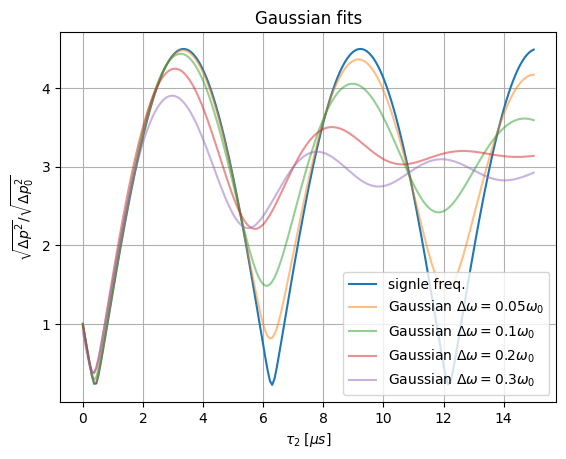

In [56]:
def g(omega, omega0, domega):
   return np.exp(- (omega-omega0)**2/2/domega**2)  / (domega*np.sqrt(2*np.pi))

def convolve(g, omega0, domega, omegas):
  dp2_mat = np.zeros((tau2.size, omegas.size))
  for i in range(len(omegas)):
      omega = omegas[i]
      phi = np.arctan( 2/(omegas[i]*tau1) )
      dp2_mat[:,i] = 1/2* (1 + (omega*tau1)**2/2 - (omega*tau1)* np.sqrt(1+(omega*tau1)**2 /4) * np.cos(2*omega*tau2 - phi)) * g(omega, omega0, domega)
  #integrate over omega (trapezoid rule)
  dp2_damped = ( np.sum(dp2_mat, 1) - 0.5*(dp2_mat[:,0]+dp2_mat[:,-1]) ) * (omegas[1]-omegas[0])

  return dp2_damped
#end

plt.plot(tau2, np.sqrt(dp2/dp2[0]), label="signle freq.")

dp2_damped = convolve(g, omega0, 0.05*omega0, omegas)
plt.plot(tau2, np.sqrt(dp2_damped/dp2[0]), label="Gaussian $\Delta \omega = 0.05 \omega_0$", alpha = 0.5)
dp2_damped = convolve(g, omega0, 0.1*omega0, omegas)
plt.plot(tau2, np.sqrt(dp2_damped/dp2[0]), label="Gaussian $\Delta \omega = 0.1 \omega_0$", alpha = 0.5)
dp2_damped = convolve(g, omega0, 0.2*omega0, omegas)
plt.plot(tau2, np.sqrt(dp2_damped/dp2[0]), label="Gaussian $\Delta \omega = 0.2 \omega_0$", alpha=0.5)
dp2_damped = convolve(g, omega0, 0.3*omega0, omegas)
plt.plot(tau2, np.sqrt(dp2_damped/dp2[0]), label="Gaussian $\Delta \omega = 0.3 \omega_0$", alpha=0.5)


plt.legend()
plt.grid()
plt.title("Gaussian fits")
plt.xlabel(r'$\tau_2 \; [\mu s]$')
plt.ylabel(r'$\sqrt{\Delta p^2}/ \sqrt{\Delta p_0^2}$')

The same is true if we try $\omega$ distributed uniformly on an interval around $\omega_0$.

<>:22: SyntaxWarning: invalid escape sequence '\D'
<>:24: SyntaxWarning: invalid escape sequence '\D'
<>:26: SyntaxWarning: invalid escape sequence '\D'
<>:28: SyntaxWarning: invalid escape sequence '\D'
<>:22: SyntaxWarning: invalid escape sequence '\D'
<>:24: SyntaxWarning: invalid escape sequence '\D'
<>:26: SyntaxWarning: invalid escape sequence '\D'
<>:28: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipython-input-2758871747.py:22: SyntaxWarning: invalid escape sequence '\D'
  plt.plot(tau2, np.sqrt(dp2_damped/dp2[0]), label="Plateau $\Delta \omega = 0.05 \omega_0$", alpha = 0.5)
/tmp/ipython-input-2758871747.py:24: SyntaxWarning: invalid escape sequence '\D'
  plt.plot(tau2, np.sqrt(dp2_damped/dp2[0]), label="Plateau $\Delta \omega = 0.1 \omega_0$", alpha = 0.5)
/tmp/ipython-input-2758871747.py:26: SyntaxWarning: invalid escape sequence '\D'
  plt.plot(tau2, np.sqrt(dp2_damped/dp2[0]), label="Plateau $\Delta \omega = 0.2 \omega_0$", alpha=0.5)
/tmp/ipython-input-2758871747.py

Text(0, 0.5, '$\\sqrt{\\Delta p^2}/ \\sqrt{\\Delta p_0^2}$')

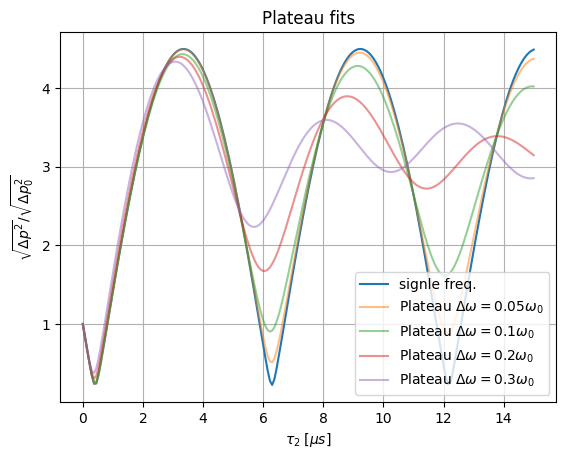

In [57]:
def g(omega, omega0, domega):
    if abs(omega-omega0)<domega :
        return 1/(2*domega)
    else:
        return 0

def convolve(g, omega0, domega, omegas):
  dp2_mat = np.zeros((tau2.size, omegas.size))
  for i in range(len(omegas)):
      omega = omegas[i]
      phi = np.arctan( 2/(omegas[i]*tau1) )
      dp2_mat[:,i] = 1/2* (1 + (omega*tau1)**2/2 - (omega*tau1)* np.sqrt(1+(omega*tau1)**2 /4) * np.cos(2*omega*tau2 - phi)) * g(omega, omega0, domega)
  #integrate over omega (trapezoid rule)
  dp2_damped = ( np.sum(dp2_mat, 1) - 0.5*(dp2_mat[:,0]+dp2_mat[:,-1]) ) * (omegas[1]-omegas[0])

  return dp2_damped
#end

plt.plot(tau2, np.sqrt(dp2/dp2[0]), label="signle freq.")

dp2_damped = convolve(g, omega0, 0.05*omega0, omegas)
plt.plot(tau2, np.sqrt(dp2_damped/dp2[0]), label="Plateau $\Delta \omega = 0.05 \omega_0$", alpha = 0.5)
dp2_damped = convolve(g, omega0, 0.1*omega0, omegas)
plt.plot(tau2, np.sqrt(dp2_damped/dp2[0]), label="Plateau $\Delta \omega = 0.1 \omega_0$", alpha = 0.5)
dp2_damped = convolve(g, omega0, 0.2*omega0, omegas)
plt.plot(tau2, np.sqrt(dp2_damped/dp2[0]), label="Plateau $\Delta \omega = 0.2 \omega_0$", alpha=0.5)
dp2_damped = convolve(g, omega0, 0.3*omega0, omegas)
plt.plot(tau2, np.sqrt(dp2_damped/dp2[0]), label="Plateau $\Delta \omega = 0.3 \omega_0$", alpha=0.5)

plt.title("Plateau fits")
plt.legend()
plt.grid()
plt.xlabel(r'$\tau_2 \; [\mu s]$')
plt.ylabel(r'$\sqrt{\Delta p^2}/ \sqrt{\Delta p_0^2}$')

I have problems fitting not only to the experimental data (by eye) but also to the fit function used by the authors. What is quite peculiar is that their fit function is somehat slant, having its peeks much steeper on the right than on the left. Obviously, this does not happen for any of my fits and given the complicated functional form of $\Delta p^2$, I find it difficult to trace properties of time-evolution curves back to the frequency distribution $g$.